In [35]:
Kwara_CPI = pd.read_excel("C:/Users/USER/Documents/Kwara CPI.xlsx")

In [36]:
Kwara_CPI

,Date,All_Items_Index,All_Items_MoM,All_Items_YoY,Food_Index,Food_MoM,Food_YoY
0,2020M4,383.96,NaN,361.08,NaN,NaN,NaN
1,2020M5,389.68,1.49,364.78,1.02,NaN,NaN
2,2020M6,391.45,0.45,368.48,1.01,NaN,NaN
3,2020M7,397.54,1.56,377.94,2.57,NaN,NaN
4,2020M8,401.19,0.92,385.36,1.96,NaN,NaN
5,2020M9,406.78,1.39,391.01,1.46,NaN,NaN
6,2020M10,416.25,2.33,406.19,3.88,NaN,NaN
7,2020M11,421.10,1.17,414.13,1.95,NaN,NaN
8,2020M12,428.20,1.68,425.04,2.63,NaN,NaN
9,2021M1,431.39,0.75,429.34,1.01,NaN,NaN


In [13]:
import pandas as pd

In [31]:
# Filter rows where All_Items_YoY > 20, handling NaN
mask = (Kwara_CPI["All_Items_YoY"].notna()) & (Kwara_CPI["All_Items_YoY"] > 20)
high_inflation = Kwara_CPI[mask]

In [32]:
# Display results
print("Months with All Items YoY > 20%:")
print(high_inflation[["Date", "All_Items_YoY"]])

Months with All Items YoY > 20%:
       Date  All_Items_YoY
0    2020M4         361.08
1    2020M5         364.78
2    2020M6         368.48
3    2020M7         377.94
4    2020M8         385.36
5    2020M9         391.01
6   2020M10         406.19
7   2020M11         414.13
8   2020M12         425.04
9    2021M1         429.34
10   2021M2         435.26
11   2021M3         447.58
29   2022M9          21.62
30  2022M10          20.64
31  2022M11          20.23
33   2023M1          20.16
34   2023M2          20.49
35   2023M3          20.23
36   2023M4          20.11
37   2023M5          20.60
38   2023M6          21.11
39   2023M7          44.53
40   2023M8          26.91
41   2023M9          26.54
42  2023M10          28.27
43  2023M11          30.13
44  2023M12          30.66
45   2024M1          29.83
46   2024M2          35.52
47   2024M3          38.09
48   2024M4          37.51
49   2024M5          36.13
50   2024M6          36.62
52   2024M8          32.02
53   2024M9          3

In [51]:
# Convert Date to Year and Month
Kwara_CPI['Year'] = Kwara_CPI['Date'].str[:4]
Kwara_CPI['Month'] = Kwara_CPI['Date'].str[5:].astype(int)
Kwara_CPI['Quarter'] = Kwara_CPI['Month'].apply(lambda x: f"Q{(x-1)//3 + 1}")

In [52]:
# Create Quarter column (e.g., 2020Q2)
Kwara_CPI['Quarter'] = Kwara_CPI['Year'] + Kwara_CPI['Quarter']

In [53]:
# Aggregate by quarter
quarterly = Kwara_CPI.groupby('Quarter').agg({
    'All_Items_Index': 'mean',
    'Food_Index': 'mean'
}).reset_index()

In [54]:
# Calculate QoQ
quarterly['All_Items_QoQ'] = quarterly['All_Items_Index'].pct_change() * 100
quarterly['Food_QoQ'] = quarterly['Food_Index'].pct_change() * 100

In [55]:
# Calculate YoY (shift by 4 quarters)
quarterly['All_Items_YoY'] = quarterly['All_Items_Index'].pct_change(periods=4) * 100
quarterly['Food_YoY'] = quarterly['Food_Index'].pct_change(periods=4) * 100

In [80]:
# Save to CSV
quarterly.to_excel('kwara_cpi_quarterly.xlsx', index=False)
quarterly

,Quarter,All_Items_Index,Food_Index,All_Items_QoQ,Food_QoQ,All_Items_YoY,Food_YoY
0,2020Q2,388.363333,1.015000,NaN,NaN,NaN,NaN
1,2020Q3,401.836667,1.996667,3.469260,96.715928,NaN,NaN
2,2020Q4,421.850000,2.820000,4.980465,41.235392,NaN,NaN
3,2021Q1,435.906667,1.740000,3.332148,-38.297872,NaN,NaN
4,2021Q2,449.446667,456.593333,3.106170,26140.996169,15.728399,44884.564860
5,2021Q3,459.243333,468.630000,2.179717,2.636190,14.286070,23370.617696
6,2021Q4,472.303333,486.686667,2.843808,3.853075,11.960017,17158.392435
7,2022Q1,495.203333,522.920000,4.848579,7.444900,13.603065,29952.873563
8,2022Q2,521.890000,562.270000,5.389032,7.525052,16.118338,23.144593
9,2022Q3,552.580000,614.213333,5.880550,9.238148,20.324011,31.065731


In [41]:
# YoY inflation
Kwara_CPI["Year"] = Kwara_CPI["Date"].str[-2:]
decembers = Kwara_CPI[Kwara_CPI["Date"].str.startswith("M12")].copy()
decembers["All_Items_YoY"] = decembers["All_Items_YoY"].pct_change() * 100
decembers["Food_YoY"] = decembers["Food_YoY"].pct_change() * 100

In [44]:
# Overall growth
all_items_growth = (Kwara_CPI["All_Items_Index"].iloc[-1] - Kwara_CPI["All_Items_Index"].iloc[0]) / Kwara_CPI["All_Items_Index"].iloc[0] * 100
food_growth = (Kwara_CPI["Food_Index"].iloc[-1] - Kwara_CPI["Food_Index"].iloc[1]) / Kwara_CPI["Food_Index"].iloc[1] * 100
print(f"All Items Growth: {all_items_growth:.1f}%, Food Growth: {food_growth:.1f}%")

All Items Growth: 161.7%, Food Growth: 119880.4%


In [21]:
import matplotlib.pyplot as plt

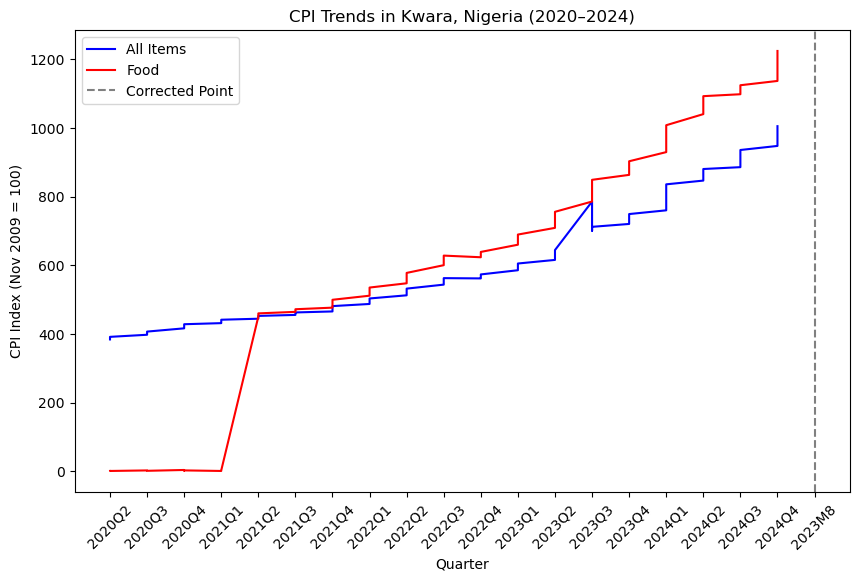

In [57]:
# Line Chart
plt.figure(figsize=(10, 6))
plt.plot(Kwara_CPI["Quarter"], Kwara_CPI["All_Items_Index"], label="All Items", color="blue")
plt.plot(Kwara_CPI["Quarter"], Kwara_CPI["Food_Index"], label="Food", color="red")
plt.axvline(x="2023M8", linestyle="--", color="gray", label="Corrected Point")
plt.xlabel("Quarter")
plt.ylabel("CPI Index (Nov 2009 = 100)")
plt.title("CPI Trends in Kwara, Nigeria (2020–2024)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [82]:
# Load quarterly data
(Kwara_CPI.head())
(Kwara_CPI.shape)
(Kwara_CPI.isna().sum())

Date                0
All_Items_Index     0
All_Items_MoM       1
All_Items_YoY       0
Food_Index          1
Food_MoM           12
Food_YoY           12
Year                0
Month               0
Quarter             0
dtype: int64

In [74]:
import matplotlib.pyplot as plt

# Filter Q4 data and drop NaN
q4_data =Kwara_CPI[Kwara_CPI['Quarter'].str.endswith('Q4')].dropna(subset=['All_Items_YoY', 'Food_YoY'])

In [75]:
# Check shapes
print(q4_data[['Quarter', 'All_Items_YoY', 'Food_YoY']])
print("Quarter shape:", q4_data['Quarter'].shape)  # Should be (4,)
print("YoY shapes:", q4_data['All_Items_YoY'].shape, q4_data['Food_YoY'].shape)  # Both (4,)

   Quarter  All_Items_YoY  Food_YoY
18  2021Q4          11.81     17.28
19  2021Q4          11.72     16.89
20  2021Q4          12.34     17.49
30  2022Q4          20.64     30.94
31  2022Q4          20.23     29.73
32  2022Q4          19.17     27.91
42  2023Q4          28.27     38.46
43  2023Q4          30.13     40.68
44  2023Q4          30.66     41.34
54  2024Q4          31.57     31.66
55  2024Q4          31.08     31.38
56  2024Q4          34.16     35.57
Quarter shape: (12,)
YoY shapes: (12,) (12,)


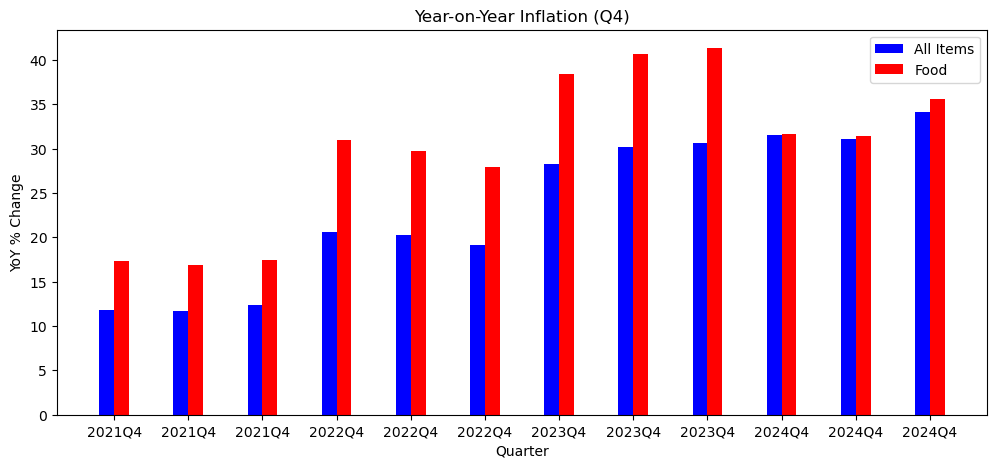

In [89]:
# Bar Chart
plt.figure(figsize=(12, 5))
bar_width = 0.20
x = range(len(q4_data))
plt.bar(x, q4_data['All_Items_YoY'], bar_width, label='All Items', color='blue')
plt.bar([i + bar_width for i in x], q4_data['Food_YoY'], bar_width, label='Food', color='red')
plt.xlabel('Quarter')
plt.ylabel('YoY % Change')
plt.title('Year-on-Year Inflation (Q4)')
plt.xticks([i + bar_width/2 for i in x], q4_data['Quarter'])
plt.legend()
plt.show()